# Assignment 3

In this assignment you will explore measures of centrality on two networks, a friendship network in Part 1, and a blog network in Part 2.

## Part 1

Answer questions 1-4 using the network `G1`, a network of friendships at a university department. Each node corresponds to a person, and an edge indicates friendship. 

*The network has been loaded as networkx graph object `G1`.*

In [1]:
import networkx as nx

G1 = nx.read_gml('assets/friendships.gml')

In [16]:
type(G1)

networkx.classes.graph.Graph

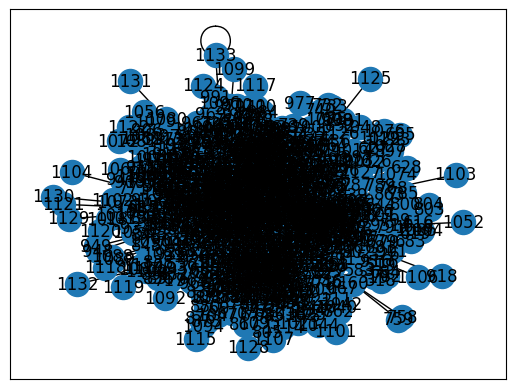

In [17]:
nx.draw_networkx(G1)

In [18]:
G1.size()

5453

In [19]:
G1.number_of_edges()

5453

In [20]:
G1.number_of_nodes()

1133

### ✅ Question 1

Find the degree centrality, closeness centrality, and betweeness centrality of node 100.

*This function should return a tuple of floats `(degree_centrality, closeness_centrality, betweenness_centrality)`.*

In [13]:
def answer_one():
    # YOUR CODE HERE
    deg_cent = nx.degree_centrality(G1)[100]
    close_cent = nx.closeness_centrality(G1)[100]
    btw_cent = nx.betweenness_centrality(G1)[100]
    return deg_cent, close_cent, btw_cent

In [14]:
ans_one = answer_one()
assert type(ans_one) == tuple, "You must return a tuple"
print(f"{ans_one}")


(0.0026501766784452294, 0.2654784240150094, 7.142902633244772e-05)


### Use centrality measures to answer questions 2-4

### ✅ Question 2

Suppose you are employed by an online shopping website and are tasked with selecting one user in network G1 to send an online shopping voucher to. We expect that the user who receives the voucher will send it to their friends in the network.  You want the voucher to reach as many nodes as possible. The voucher can be forwarded to multiple users at the same time, but the travel distance of the voucher is limited to one step, which means if the voucher travels more than one step in this network, it is no longer valid. Apply your knowledge in network centrality to select the best candidate for the voucher. 

*This function should return an integer, the chosen node.*

In [ ]:
# degree centrality is a measure of how many direct
# connections the node has. (Important because must
# travel only 1 step)
dc = nx.degree_centrality(G1)
sorted_nodes = sorted([_ for _ in dc.items()], key=lambda x: x[1], reverse=True)
sorted_nodes[:5]

[(105, 0.0636042402826855),
 (23, 0.045936395759717315),
 (333, 0.045936395759717315),
 (16, 0.045053003533568906),
 (42, 0.045053003533568906)]

In [31]:
G1.degree

DegreeView({1: 30, 2: 23, 3: 38, 4: 22, 5: 10, 6: 21, 7: 26, 8: 8, 9: 17, 10: 32, 11: 20, 12: 18, 13: 25, 14: 36, 15: 19, 16: 51, 17: 7, 18: 18, 19: 28, 20: 17, 21: 43, 22: 15, 23: 52, 24: 42, 25: 20, 26: 3, 27: 21, 28: 12, 29: 9, 30: 26, 31: 22, 32: 3, 33: 8, 34: 19, 35: 1, 36: 1, 37: 1, 38: 25, 39: 28, 40: 27, 41: 49, 42: 51, 43: 10, 44: 18, 45: 31, 46: 36, 47: 7, 48: 7, 49: 40, 50: 26, 51: 22, 52: 38, 53: 2, 54: 32, 55: 15, 56: 35, 57: 28, 58: 33, 59: 19, 60: 3, 61: 10, 62: 26, 63: 10, 64: 17, 65: 18, 66: 14, 67: 14, 68: 16, 69: 30, 70: 23, 71: 13, 72: 37, 73: 21, 74: 21, 75: 12, 76: 43, 77: 8, 78: 12, 79: 12, 80: 26, 81: 24, 82: 23, 83: 6, 84: 15, 85: 22, 86: 11, 87: 6, 88: 12, 89: 8, 90: 22, 91: 12, 92: 13, 93: 19, 94: 24, 95: 5, 96: 7, 97: 2, 98: 5, 99: 5, 100: 3, 101: 13, 102: 3, 103: 6, 104: 16, 105: 72, 106: 31, 107: 16, 108: 7, 109: 2, 110: 10, 111: 1, 112: 19, 113: 13, 114: 6, 115: 13, 116: 38, 117: 16, 118: 9, 119: 9, 120: 32, 121: 12, 122: 14, 123: 3, 124: 17, 125: 11, 126

Get max of `degree`

In [39]:
max(G1.degree, key=lambda x: x[1])

(105, 72)

Get max of `degree_centrality` values (a tuple)

In [35]:
max(nx.degree_centrality(G1).items(), key=lambda x: x[1])

(105, 0.0636042402826855)

Get the key (node) whose value is highest

In [ ]:
max(dc, key=dc.get)

105

This is functionally equivalent to

In [41]:
max(dc.items(), key=lambda x: x[1])[0]

105

In [45]:
def answer_two():
    # YOUR CODE HERE
    dc = nx.degree_centrality(G1)
    return max(dc, key=dc.get)

In [46]:
ans_two = answer_two()
ans_two

105

### ✅ Question 3

Now the limit of the voucher’s travel distance has been removed. Because the network is connected, regardless of who you pick, every node in the network will eventually receive the voucher. However, we now want to ensure that the voucher reaches nodes as quickly as possible (i.e. in the fewest number of hops). How will you change your selection strategy? Write a function to tell us who is the best candidate in the network under this condition.

*This function should return an integer, the chosen node.*

This time we can use `closeness_centrality`.  
A node’s closeness centrality is the reciprocal
of the average shortest path length to all other nodes.

In [48]:
cc = nx.closeness_centrality(G1)
max(cc, key=cc.get)

23

In [55]:
sorted(cc.items(), key=lambda x: x[1], reverse=True)[:5]

[(23, 0.3847722637661455),
 (333, 0.3828204261075414),
 (105, 0.38063214525891054),
 (42, 0.3775850567044696),
 (41, 0.3749585955614442)]

In [50]:
def answer_three():
    cc = nx.closeness_centrality(G1)
    return max(cc, key=cc.get)

In [51]:
ans_three = answer_three()
ans_three

23

### ✅ Question 4

Assume the restriction on the voucher’s travel distance is still removed, but now a competitor has developed a strategy to remove a person from the network in order to disrupt the distribution of your company’s voucher. You competitor plans to remove people who act as bridges in the network. Identify the best possible person to be removed by your competitor?

*This function should return an integer, the chosen node.*

In this case, we want to look at `betweenness`. 


In [56]:
bc = nx.betweenness_centrality(G1)

In [58]:
sorted(bc.items(), key=lambda x: x[1], reverse=True)[:5]

[(333, 0.03939111019601939),
 (105, 0.03831321200706208),
 (23, 0.03488420303387586),
 (578, 0.031546454811677095),
 (76, 0.03007667872671039)]

In [59]:
max(bc, key=bc.get)

333

In [60]:
def answer_four():
    bc = nx.betweenness_centrality(G1)
    return max(bc, key=bc.get)

In [61]:
ans_four = answer_four()
ans_four

333

## Part 2

`G2` is a directed network of political blogs, where nodes correspond to a blog and edges correspond to links between blogs. Use your knowledge of PageRank and HITS to answer Questions 5-9.

In [62]:
G2 = nx.read_gml('assets/blogs.gml')

In [63]:
type(G2)

networkx.classes.digraph.DiGraph

In [64]:
import social_networks.describe as describe

In [65]:
describe.describe_graph_2(G2)

[yellow]Path metric calculation failed:[/yellow] Graph is not strongly connected.


{'summary': {'type': 'DiGraph',
  'directed': True,
  'multigraph': False,
  'num_nodes': 1490,
  'num_edges': 19025},
 'degree_stats': {'avg_degree': 25.536912751677853,
  'max_in_degree': 337,
  'max_out_degree': 256},
 'components': {'num_weakly_connected_components': 268,
  'largest_wcc_size': 1222,
  'num_strongly_connected_components': 688,
  'largest_scc_size': 793},
 'shortest_path': {},
 'edge_attrs': {}}

### ✅ Question 5

Apply the Scaled Page Rank Algorithm to this network. Find the Page Rank of node 'realclearpolitics.com' with damping value 0.85.

*This function should return a float.*

In [68]:
pr = nx.pagerank(G2, alpha=0.85)
pr['realclearpolitics.com']

0.004636694781649098

In [67]:
pr

{'tsrightdominion.blogspot.com': 0.00034787826123863585,
 'rightrainbow.com': 0.0004286700876475778,
 'gregpalast.com': 0.002149383652281393,
 'younglibs.com': 0.00021555645931858384,
 'blotts.org/polilog': 0.00018740248208077342,
 'marylandpolitics.blogspot.com': 0.00018740248208077342,
 'blogitics.com': 0.0002449721617548766,
 'thesakeofargument.com': 0.0002989949277473624,
 'joebrent.blogspot.com': 0.00018740248208077342,
 'thesiliconmind.blogspot.com': 0.00018740248208077342,
 'kippsblog.com': 0.00018740248208077342,
 'progressivetrail.org/blog.shtml': 0.00018740248208077342,
 'randomjottings.net': 0.0004394743214390715,
 'rightvoices.com': 0.00043791575641368514,
 '84rules.blog-city.com': 0.00018740248208077342,
 'blogs.salon.com/0002874': 0.00220422764231655,
 'alvintostig.typepad.com': 0.0003620007262167064,
 'notgeniuses.com': 0.0012257303648885753,
 'democratreport.blogspot.com': 0.00019744757272093617,
 'victorhanson.com': 0.0022248558929737496,
 'aldaron.modblog.com': 0.0001

In [69]:
def answer_five():
    pr = nx.pagerank(G2, alpha=0.85)
    return pr["realclearpolitics.com"]

In [70]:
ans_five = answer_five()
ans_five

0.004636694781649098

### ✅ Question 6

Apply the Scaled Page Rank Algorithm to this network with damping value 0.85. Find the 5 nodes with highest Page Rank. 

*This function should return a list of the top 5 blogs in desending order of Page Rank.*

In [71]:
sorted(pr, key=pr.get, reverse=True)[:5]

['dailykos.com',
 'atrios.blogspot.com',
 'instapundit.com',
 'blogsforbush.com',
 'talkingpointsmemo.com']

In [74]:
def answer_six():
    pr = nx.pagerank(G2, alpha=0.85)
    return sorted(pr, key=pr.get, reverse=True)[:5]

In [75]:
ans_six = answer_six()
assert type(ans_six) == list, "You must return a list"
ans_six

['dailykos.com',
 'atrios.blogspot.com',
 'instapundit.com',
 'blogsforbush.com',
 'talkingpointsmemo.com']

### ✅ Question 7

Apply the HITS Algorithm to the network to find the hub and authority scores of node 'realclearpolitics.com'. 

*Your result should return a tuple of floats `(hub_score, authority_score)`.*

In [ ]:
hubs, auths = nx.hits(G2)
node = 'realclearpolitics.com' 
hubs[node], auths[node]

In [85]:
def answer_seven():
    hubs, auths = nx.hits(G2)
    node = 'realclearpolitics.com' 
    return hubs[node], auths[node]

In [86]:
ans_seven = answer_seven()
assert type(ans_seven) == tuple, "You must return a tuple"
ans_seven

(0.0003243556140278732, 0.003918957644934257)

### ✅ Question 8 

Apply the HITS Algorithm to this network to find the 5 nodes with highest hub scores.

*This function should return a list of the top 5 blogs in desending order of hub scores.*

In [87]:
def answer_eight():
    hubs, _ = nx.hits(G2)
    return sorted(hubs, key=hubs.get, reverse=True)[:5]

In [88]:
ans_eight = answer_eight()
assert type(ans_eight) == list, "You must return a list"
ans_eight

['politicalstrategy.org',
 'madkane.com/notable.html',
 'liberaloasis.com',
 'stagefour.typepad.com/commonprejudice',
 'bodyandsoul.typepad.com']

### ✅ Question 9 

Apply the HITS Algorithm to this network to find the 5 nodes with highest authority scores.

*This function should return a list of the top 5 blogs in desending order of authority scores.*

In [89]:
def answer_nine():
    _, auths = nx.hits(G2)
    return sorted(auths, key=auths.get, reverse=True)[:5]

In [90]:
ans_nine = answer_nine()
assert type(ans_nine) == list, "You must return a list"
ans_nine

['dailykos.com',
 'talkingpointsmemo.com',
 'atrios.blogspot.com',
 'washingtonmonthly.com',
 'talkleft.com']